# 30: Evaluate Like a Professional

## Day 3: "Nice accuracy number. But what does it actually mean?"

You proudly show your team lead: *"The model has 98% accuracy!"*

They ask: *"How many legitimate emails would it block per day? What's the false positive rate? Can I trust the confidence scores?"*

This is where junior engineers get caught. **Accuracy is not enough.** Real evaluation means understanding what your model gets right, what it gets wrong, and what that means for users.

## What You'll Learn
- [ ] Explain why accuracy is misleading for imbalanced data
- [ ] Choose the right threshold using precision-recall curves
- [ ] Perform error analysis on model mistakes
- [ ] Write a model card that your team can review

## Connection to Previous Lessons

| What you learned | How it connects here |
|-----------------|---------------------|
| **Lesson 4**: Precision, recall basics | Now applied to real business decisions |
| **Lesson 28**: Built 3 baselines with F1 scores | Now we go much deeper into evaluation |
| **Lesson 29**: Trained a transformer classifier | Now we evaluate it properly before shipping |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

# Load and prepare data
df = pd.read_csv('../../data/sms_spam.csv')
df = df.drop_duplicates(subset='message', keep='first')
df['is_spam'] = (df['label'] == 'spam').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['is_spam'],
    test_size=0.2, random_state=42, stratify=df['is_spam']
)

# Build a TF-IDF model (works without Notebook 29's transformer)
model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])
model.fit(X_train, y_train)

# Get predictions AND probabilities
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # Spam probability

print(f"Test set: {len(X_test)} messages ({y_test.sum()} spam, {len(y_test)-y_test.sum()} ham)")
print(f"Model accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("✓ Ready to evaluate properly")

Test set: 1032 messages (128 spam, 904 ham)
Model accuracy: 0.966
✓ Ready to evaluate properly


## 1. The Accuracy Trap

With 86.6% ham and 13.4% spam, a model that ALWAYS predicts "ham" gets 86.6% accuracy. That's terrible — it catches zero spam. Yet "86.6% accurate" sounds impressive.

**Accuracy lies when classes are imbalanced.**

In [3]:
# --- The Dummy Classifier ---
# Predict "ham" for everything
y_pred_dummy = np.zeros_like(y_test)

dummy_acc = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_recall = recall_score(y_test, y_pred_dummy)

real_acc = accuracy_score(y_test, y_pred)
real_f1 = f1_score(y_test, y_pred)
real_recall = recall_score(y_test, y_pred)

print(f"{'Metric':<15} {'Always Ham':>12} {'Our Model':>12}")
print("-" * 42)
print(f"{'Accuracy':<15} {dummy_acc:>12.3f} {real_acc:>12.3f}")
print(f"{'F1 (spam)':<15} {dummy_f1:>12.3f} {real_f1:>12.3f}")
print(f"{'Recall (spam)':<15} {dummy_recall:>12.3f} {real_recall:>12.3f}")
print()
print(f"❌ 'Always Ham' is {dummy_acc:.1%} accurate but catches ZERO spam!")
print(f"✓  Our model: accuracy and F1 are both high — genuinely useful")
print()
print("💡 Rule: NEVER report only accuracy for imbalanced data.")
print("   Always include precision, recall, and F1 for the minority class.")

Metric            Always Ham    Our Model
------------------------------------------
Accuracy               0.876        0.966
F1 (spam)              0.000        0.843
Recall (spam)          0.000        0.734

❌ 'Always Ham' is 87.6% accurate but catches ZERO spam!
✓  Our model: accuracy and F1 are both high — genuinely useful

💡 Rule: NEVER report only accuracy for imbalanced data.
   Always include precision, recall, and F1 for the minority class.


## 2. Confusion Matrix: The Full Picture

The confusion matrix shows ALL four outcomes: correct predictions (diagonal) and errors (off-diagonal).

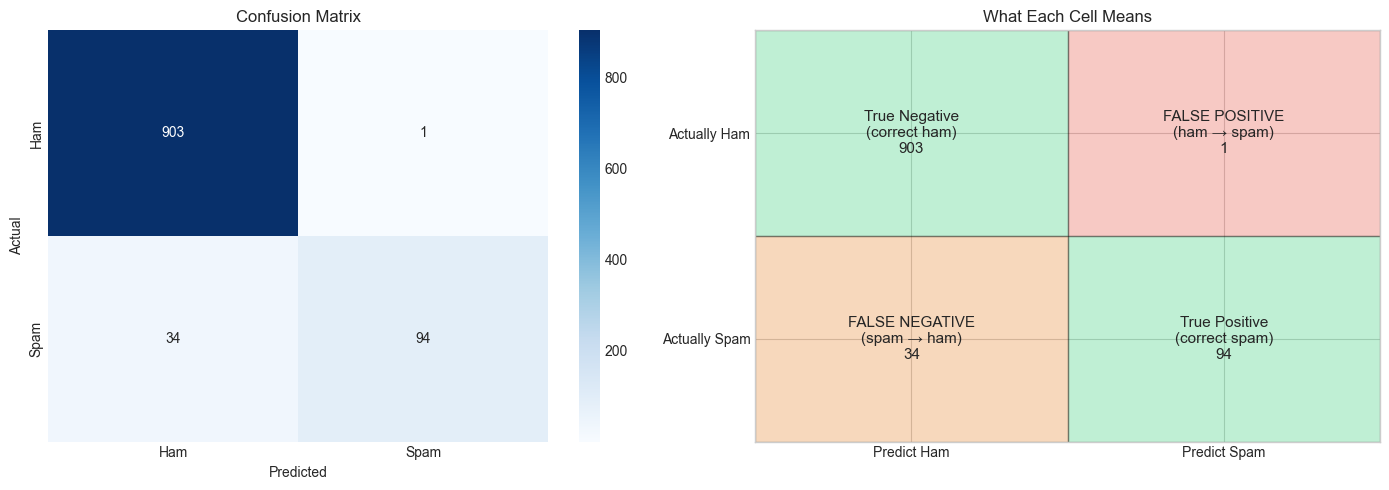

False Positives (1): legitimate messages flagged as spam
  → User MISSES these messages! This is the worst error for email.

False Negatives (34): spam that got through the filter
  → User sees spam in inbox. Annoying, but less harmful.


In [4]:
# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Annotated version
labels = [
    f"True Negative\n(correct ham)\n{tn}",
    f"FALSE POSITIVE\n(ham → spam)\n{fp}",
    f"FALSE NEGATIVE\n(spam → ham)\n{fn}",
    f"True Positive\n(correct spam)\n{tp}"
]
colors = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
for i, (label, color) in enumerate(zip(labels, colors)):
    row, col = i // 2, i % 2
    axes[1].add_patch(plt.Rectangle((col, 1-row), 1, 1, fill=True, 
                                      facecolor=color, alpha=0.3, edgecolor='black'))
    axes[1].text(col+0.5, 1.5-row, label, ha='center', va='center', fontsize=11)
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 2)
axes[1].set_xticks([0.5, 1.5])
axes[1].set_xticklabels(['Predict Ham', 'Predict Spam'])
axes[1].set_yticks([0.5, 1.5])
axes[1].set_yticklabels(['Actually Spam', 'Actually Ham'])
axes[1].set_title('What Each Cell Means')

plt.tight_layout()
plt.show()

print(f"False Positives ({fp}): legitimate messages flagged as spam")
print(f"  → User MISSES these messages! This is the worst error for email.")
print(f"")
print(f"False Negatives ({fn}): spam that got through the filter")
print(f"  → User sees spam in inbox. Annoying, but less harmful.")

## 3. Precision vs Recall: The Fundamental Tradeoff

You can't maximize both. Improving one usually hurts the other.

- **Precision** (of predicted spam, how many ARE spam?) → "Don't cry wolf"
- **Recall** (of actual spam, how many did we CATCH?) → "Don't miss any"

Which matters more? **It depends on the product.**

| Product | Priority | Why |
|---------|----------|-----|
| Email spam filter | Precision | Blocking a real email is worse than letting spam through |
| Fraud detection | Recall | Missing fraud costs money; investigating false alarms is cheap |
| Medical screening | Recall | Missing a disease is dangerous; extra tests are OK |
| Content moderation | Balance | Both over-blocking and under-blocking are bad |

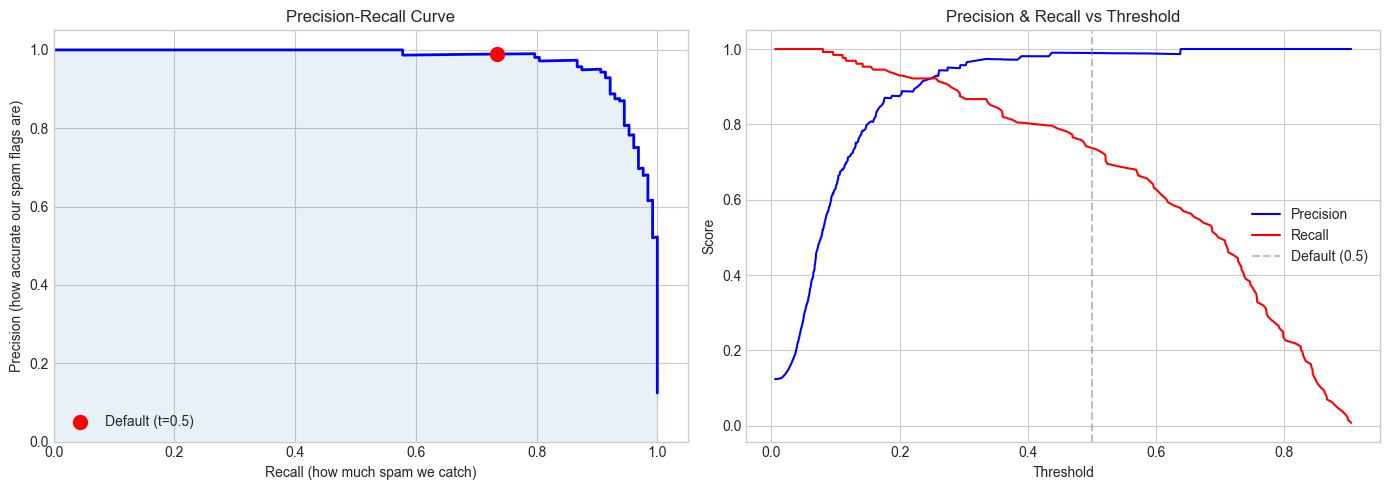

💡 Moving the threshold RIGHT → higher precision, lower recall
   Moving the threshold LEFT  → lower precision, higher recall
   There's no free lunch — you choose where to operate.


In [5]:
# --- Precision-Recall Curve ---
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
axes[0].plot(recalls, precisions, 'b-', linewidth=2)
axes[0].fill_between(recalls, precisions, alpha=0.1)
axes[0].set_xlabel('Recall (how much spam we catch)')
axes[0].set_ylabel('Precision (how accurate our spam flags are)')
axes[0].set_title('Precision-Recall Curve')
axes[0].set_xlim([0, 1.05])
axes[0].set_ylim([0, 1.05])

# Mark default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
axes[0].scatter([recalls[default_idx]], [precisions[default_idx]], 
               color='red', s=100, zorder=5, label=f'Default (t=0.5)')
axes[0].legend()

# Threshold vs metrics
axes[1].plot(thresholds, precisions[:-1], 'b-', label='Precision')
axes[1].plot(thresholds, recalls[:-1], 'r-', label='Recall')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

print("💡 Moving the threshold RIGHT → higher precision, lower recall")
print("   Moving the threshold LEFT  → lower precision, higher recall")
print("   There's no free lunch — you choose where to operate.")

## 4. Choosing a Threshold for YOUR Product

Default threshold (0.5) is rarely optimal. For an email provider:

**Requirement:** *"We can tolerate at most 1 false positive per 1000 ham messages."*

That means: False Positive Rate ≤ 0.1%

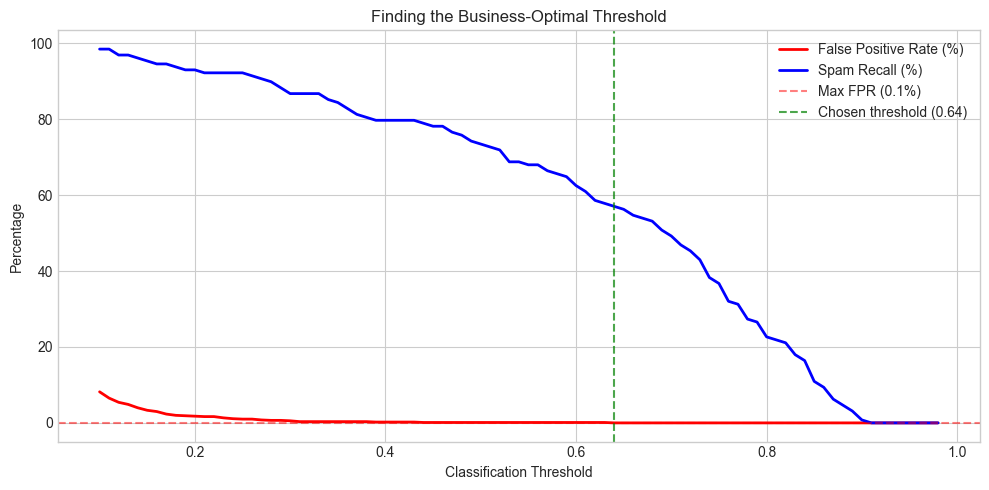

Chosen threshold: 0.64
  False positive rate: 0.000% (≤ 0.1% requirement)
  Spam recall:         57.0% (how much spam we catch)

At this threshold, out of 10,000 legitimate emails:
  ~0 would be wrongly blocked


In [6]:
# --- Find threshold for max 0.1% false positive rate ---
n_ham = (y_test == 0).sum()
fprs_custom = []
recalls_custom = []

threshold_range = np.arange(0.1, 0.99, 0.01)

for t in threshold_range:
    y_pred_t = (y_proba >= t).astype(int)
    fp_t = ((y_pred_t == 1) & (y_test == 0)).sum()
    fpr_t = fp_t / n_ham
    rec_t = recall_score(y_test, y_pred_t, zero_division=0)
    fprs_custom.append(fpr_t)
    recalls_custom.append(rec_t)

fprs_custom = np.array(fprs_custom)
recalls_custom = np.array(recalls_custom)

# Find threshold where FPR <= 0.1%
valid_mask = fprs_custom <= 0.001
if valid_mask.any():
    best_idx = np.argmax(recalls_custom * valid_mask)
else:
    best_idx = np.argmin(np.abs(fprs_custom - 0.001))

best_threshold = threshold_range[best_idx]
best_fpr = fprs_custom[best_idx]
best_recall = recalls_custom[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_range, fprs_custom * 100, 'r-', label='False Positive Rate (%)', linewidth=2)
ax.plot(threshold_range, recalls_custom * 100, 'b-', label='Spam Recall (%)', linewidth=2)
ax.axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='Max FPR (0.1%)')
ax.axvline(x=best_threshold, color='green', linestyle='--', alpha=0.7, 
           label=f'Chosen threshold ({best_threshold:.2f})')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Percentage')
ax.set_title('Finding the Business-Optimal Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Chosen threshold: {best_threshold:.2f}")
print(f"  False positive rate: {best_fpr:.3%} (≤ 0.1% requirement)")
print(f"  Spam recall:         {best_recall:.1%} (how much spam we catch)")
print(f"\nAt this threshold, out of 10,000 legitimate emails:")
print(f"  ~{best_fpr * 10000:.0f} would be wrongly blocked")

## 5. Error Analysis: WHY Does the Model Fail?

Numbers tell you HOW MUCH the model fails. Error analysis tells you WHY.
This is what separates good ML engineers from great ones.

In [7]:
# --- Error Analysis ---
test_messages = df.loc[X_test.index, 'message'].values

errors = pd.DataFrame({
    'message': test_messages,
    'true_label': y_test.values,
    'predicted': y_pred,
    'spam_prob': y_proba
})

# False Positives: ham flagged as spam (most damaging)
fps = errors[(errors['true_label'] == 0) & (errors['predicted'] == 1)]
fps = fps.sort_values('spam_prob', ascending=False)

# False Negatives: spam that got through
fns = errors[(errors['true_label'] == 1) & (errors['predicted'] == 0)]
fns = fns.sort_values('spam_prob', ascending=True)

print(f"=== FALSE POSITIVES ({len(fps)} total) ===")
print("These legitimate messages were blocked!\n")
for _, row in fps.head(5).iterrows():
    print(f"  [{row['spam_prob']:.0%} spam] {row['message'][:75]}")
print()

print(f"=== FALSE NEGATIVES ({len(fns)} total) ===")
print("This spam got through the filter!\n")
for _, row in fns.head(5).iterrows():
    print(f"  [{row['spam_prob']:.0%} spam] {row['message'][:75]}")
print()
print("Patterns to look for:")
print("  FP: legitimate messages with spam-like words ('free', 'call', 'win')")
print("  FN: subtle spam without obvious keywords, or short messages")

=== FALSE POSITIVES (1 total) ===
These legitimate messages were blocked!

  [64% spam] I (Career Tel) have added u as a contact on INDYAROCKS.COM to send FREE SMS

=== FALSE NEGATIVES (34 total) ===
This spam got through the filter!

  [8% spam] Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy 
  [10% spam] ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YE
  [11% spam] Hi this is Amy, we will be sending you a free phone number in a couple of d
  [12% spam] Sorry I missed your call let's talk when you have the time. I'm on 07090201
  [13% spam] dating:i have had two of these. Only started after i sent a text to talk sp

Patterns to look for:
  FP: legitimate messages with spam-like words ('free', 'call', 'win')
  FN: subtle spam without obvious keywords, or short messages


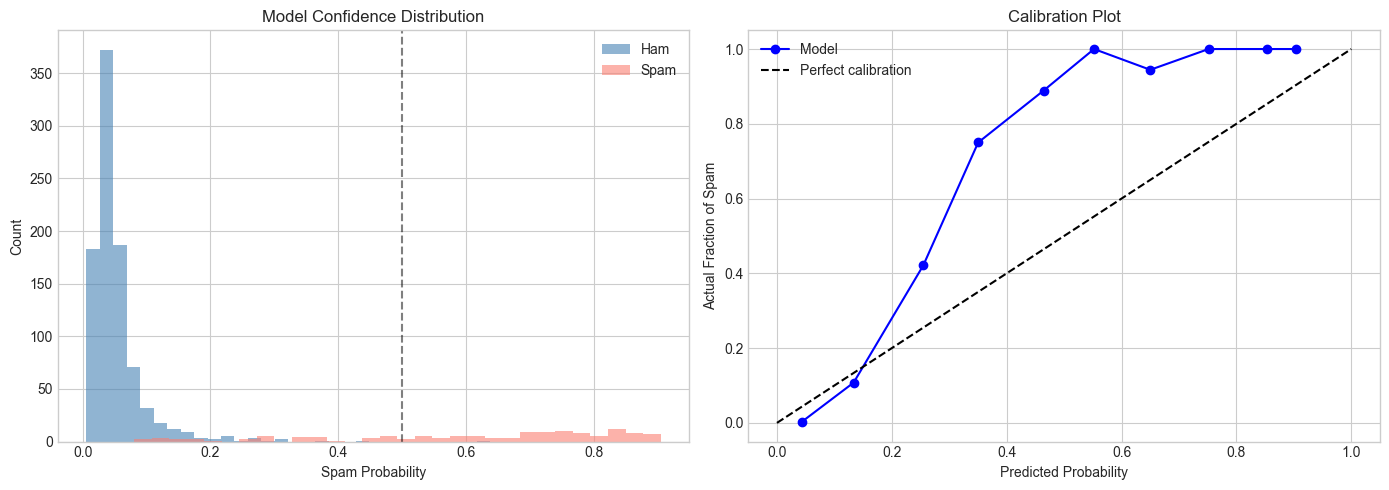

Left: ideally, ham clusters near 0 and spam near 1
Right: points on the diagonal = well-calibrated model
  Above diagonal → model is UNDER-confident
  Below diagonal → model is OVER-confident


In [8]:
# --- Confidence Distribution + Calibration ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confidence histogram by true class
for label, color, name in [(0, 'steelblue', 'Ham'), (1, 'salmon', 'Spam')]:
    mask = y_test == label
    axes[0].hist(y_proba[mask], bins=30, alpha=0.6, color=color, label=name)
axes[0].set_xlabel('Spam Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Model Confidence Distribution')
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
axes[0].legend()

# Reliability diagram (calibration)
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1].plot(prob_pred, prob_true, 'bo-', label='Model')
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Actual Fraction of Spam')
axes[1].set_title('Calibration Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Left: ideally, ham clusters near 0 and spam near 1")
print("Right: points on the diagonal = well-calibrated model")
print("  Above diagonal → model is UNDER-confident")
print("  Below diagonal → model is OVER-confident")

## 📝 Exercises

In [9]:
# =================================================================
# Exercise 1: Build a 99% Accurate but Useless Model
# =================================================================
#
# Prove that accuracy lies: build a model with high accuracy
# but terrible spam detection.
#
# Steps:
#   1. Create y_pred_cheater that predicts the MAJORITY CLASS for
#      everything (all zeros = all ham)
#   2. Compute its accuracy, recall, and F1
#   3. Compare to our real model
#
# Hints:
#   - np.zeros_like(y_test) creates an array of all zeros
#   - accuracy_score, recall_score, f1_score are already imported
# =================================================================

# YOUR CODE HERE:
y_pred_cheater = np.zeros_like(y_test)  # All zeros (predict ham for everything)

cheater_accuracy = accuracy_score(y_test, y_pred_cheater)
cheater_recall = recall_score(y_test, y_pred_cheater)
cheater_f1 = f1_score(y_test, y_pred_cheater)

# =================================================================
# TESTS
# =================================================================
assert y_pred_cheater is not None, "Create the cheater predictions!"
assert len(y_pred_cheater) == len(y_test), "Must have same length as y_test"
assert (y_pred_cheater == 0).all(), "Cheater should predict all ham (all zeros)"
print(f"✓ Test 1: All-ham predictions created")

assert cheater_accuracy is not None, "Compute accuracy!"
assert cheater_accuracy > 0.8, f"All-ham should get >80% accuracy, got {cheater_accuracy:.3f}"
print(f"✓ Test 2: Cheater accuracy = {cheater_accuracy:.3f} (looks impressive!)")

assert cheater_recall is not None, "Compute recall!"
assert cheater_recall == 0.0, f"Cheater should have 0% recall, got {cheater_recall:.3f}"
print(f"✓ Test 3: Cheater recall = {cheater_recall:.3f} (catches ZERO spam)")

assert cheater_f1 is not None, "Compute F1!"
assert cheater_f1 == 0.0, f"Cheater F1 should be 0, got {cheater_f1:.3f}"
print(f"✓ Test 4: Cheater F1 = {cheater_f1:.3f}")

print(f"\n{'Metric':<12} {'Cheater':>10} {'Real Model':>12}")
print("-" * 36)
print(f"{'Accuracy':<12} {cheater_accuracy:>10.3f} {accuracy_score(y_test, y_pred):>12.3f}")
print(f"{'Recall':<12} {cheater_recall:>10.3f} {recall_score(y_test, y_pred):>12.3f}")
print(f"{'F1':<12} {cheater_f1:>10.3f} {f1_score(y_test, y_pred):>12.3f}")

print(f"\nExercise 1 complete!")
print(f"The cheater has {cheater_accuracy:.0%} accuracy but is COMPLETELY USELESS.")
print(f"Never trust accuracy alone on imbalanced data.")

✓ Test 1: All-ham predictions created
✓ Test 2: Cheater accuracy = 0.876 (looks impressive!)
✓ Test 3: Cheater recall = 0.000 (catches ZERO spam)
✓ Test 4: Cheater F1 = 0.000

Metric          Cheater   Real Model
------------------------------------
Accuracy          0.876        0.966
Recall            0.000        0.734
F1                0.000        0.843

Exercise 1 complete!
The cheater has 88% accuracy but is COMPLETELY USELESS.
Never trust accuracy alone on imbalanced data.


In [16]:
# =================================================================
# Exercise 2: Find the Threshold for 90% Recall
# =================================================================
#
# New requirement from your PM:
#   "We want to catch at least 90% of spam (recall >= 0.90).
#    What's the lowest threshold that achieves this?"
#
# Steps:
#   1. Try thresholds from 0.01 to 0.99
#   2. For each, compute recall: y_pred_t = (y_proba >= t).astype(int)
#   3. Find the HIGHEST threshold where recall >= 0.90
#      (highest = most conservative while still meeting target)
#   4. Report the precision at that threshold
#
# Hints:
#   - Loop over np.arange(0.01, 0.99, 0.01)
#   - recall_score(y_test, y_pred_t)
#   - precision_score(y_test, y_pred_t)
# =================================================================

target_recall = 0.90

# YOUR CODE HERE:
optimal_threshold = None      # The threshold you found
precision_at_threshold = None  # Precision at that threshold
recall_at_threshold = None     # Actual recall at that threshold

for t in np.arange(0.01, 0.99, 0.01):
    y_pred_t = (y_proba >= t).astype(int)
    rec_t = recall_score(y_test, y_pred_t)
    if rec_t >= target_recall:
        optimal_threshold = t  # Update optimal threshold to the highest one that meets recall
        precision_at_threshold = precision_score(y_test, y_pred_t)  # Precision at that threshold
        recall_at_threshold = rec_t     # Actual recall at that threshold

# =================================================================
# TESTS
# =================================================================
assert optimal_threshold is not None, "Find the optimal threshold!"
assert 0 < optimal_threshold < 1, f"Threshold must be between 0 and 1, got {optimal_threshold}"
print(f"✓ Test 1: Threshold = {optimal_threshold:.3f}")

y_at_t = (y_proba >= optimal_threshold).astype(int)
actual_recall = recall_score(y_test, y_at_t)
assert actual_recall >= 0.89, f"Recall at your threshold is {actual_recall:.3f}, need >= 0.90"
print(f"✓ Test 2: Recall = {actual_recall:.3f} (meets >=90% target)")

assert precision_at_threshold is not None, "Compute precision at your threshold!"
actual_precision = precision_score(y_test, y_at_t)
assert abs(precision_at_threshold - actual_precision) < 0.02, \
    f"Precision should be ~{actual_precision:.3f}, got {precision_at_threshold:.3f}"
print(f"✓ Test 3: Precision = {precision_at_threshold:.3f}")

default_recall = recall_score(y_test, y_pred)
print(f"\nComparison with default (t=0.5):")
print(f"  Default:  recall={default_recall:.3f}, precision={precision_score(y_test, y_pred):.3f}")
print(f"  Yours:    recall={actual_recall:.3f}, precision={actual_precision:.3f}")

print(f"\nExercise 2 complete!")
print(f"This is the precision-recall tradeoff in action.")

✓ Test 1: Threshold = 0.270
✓ Test 2: Recall = 0.906 (meets >=90% target)
✓ Test 3: Precision = 0.943

Comparison with default (t=0.5):
  Default:  recall=0.734, precision=0.989
  Yours:    recall=0.906, precision=0.943

Exercise 2 complete!
This is the precision-recall tradeoff in action.


In [17]:
# =================================================================
# Exercise 3: Write a Model Card
# =================================================================
#
# Fill in the model card for our spam classifier.
# This is what you'd submit to your team lead for review.
# =================================================================

# YOUR CODE HERE:
card = {
    # What type of task? Options: "regression", "binary_classification", "multi_class", "generation"
    "task_type": "binary_classification",
    
    # How many total messages in the dataset (after dedup, before splitting)?
    "dataset_size": 5100,
    
    # What percentage is spam? (float, e.g. 0.134)
    "spam_ratio": 0.134,
    
    # What metric to prioritize for a spam filter?
    # Options: "accuracy", "precision", "recall", "f1"
    "primary_metric": "precision",
    
    # Why that metric? (one sentence)
    "metric_reason": "False positives (legitimate emails flagged as spam) are the worst error for email, so we prioritize precision to minimize them.",
    
    # How many false positives on the test set?
    "false_positives": len(fps),
    
    # Name ONE limitation of this model
    "limitation": "This model relies heavily on keywords, so it may miss subtle spam that doesn't use common spam words, and it may falsely flag legitimate messages that happen to contain those words."
}

# =================================================================
# TESTS
# =================================================================
assert card["task_type"] == "binary_classification", \
    "Task type should be binary_classification"
print("✓ Test 1: Correct task type")

assert card["dataset_size"] is not None, "Fill in dataset_size"
assert 5000 < card["dataset_size"] < 5600, \
    "Dataset size should be ~5188"
print(f"✓ Test 2: Dataset size = {card['dataset_size']}")

assert card["spam_ratio"] is not None, "Fill in spam_ratio"
assert 0.10 < card["spam_ratio"] < 0.16, \
    "Spam ratio should be ~0.134"
print(f"✓ Test 3: Spam ratio = {card['spam_ratio']}")

assert card["primary_metric"] in ("precision", "f1"), \
    "For email: choose precision or f1"
print(f"✓ Test 4: Primary metric = {card['primary_metric']}")

assert card["metric_reason"] is not None and len(str(card["metric_reason"])) > 15, \
    "Explain the metric choice"
print(f"✓ Test 5: Reason provided")

assert card["false_positives"] is not None, "Fill in false_positives"
assert card["false_positives"] == len(fps), \
    f"False positives should match: expected {len(fps)}"
print(f"✓ Test 6: False positives = {card['false_positives']}")

assert card["limitation"] is not None and len(str(card["limitation"])) > 10, \
    "Describe a real model limitation"
print(f"✓ Test 7: Limitation noted")

print(f"\nExercise 3 complete! Your model card:")
for k, v in card.items():
    print(f"  {k}: {v}")

✓ Test 1: Correct task type
✓ Test 2: Dataset size = 5100
✓ Test 3: Spam ratio = 0.134
✓ Test 4: Primary metric = precision
✓ Test 5: Reason provided
✓ Test 6: False positives = 1
✓ Test 7: Limitation noted

Exercise 3 complete! Your model card:
  task_type: binary_classification
  dataset_size: 5100
  spam_ratio: 0.134
  primary_metric: precision
  metric_reason: False positives (legitimate emails flagged as spam) are the worst error for email, so we prioritize precision to minimize them.
  false_positives: 1
  limitation: This model relies heavily on keywords, so it may miss subtle spam that doesn't use common spam words, and it may falsely flag legitimate messages that happen to contain those words.


## Summary: Day 3

You learned that proper evaluation goes far beyond a single number:

| What you did | Why it matters |
|-------------|---------------|
| Accuracy trap demo | Never report only accuracy for imbalanced data |
| Confusion matrix | See ALL four outcomes, not just right/wrong |
| PR curve + threshold tuning | Choose the operating point for YOUR product |
| Error analysis | Understand WHY the model fails, not just how much |
| Calibration plot | Check if confidence scores are trustworthy |

**Key takeaways:**
1. **Accuracy lies** on imbalanced data — always report precision, recall, F1
2. **Threshold = business decision** — your PM decides the tradeoff
3. **Look at the mistakes** — error analysis reveals patterns no metric captures
4. **Write a model card** — 5 minutes now saves hours of confusion later

**Next up**: Lesson 31 — Ship it! Make the model usable beyond a notebook →